        MODEL ACCURACY REPORT
  R² Accuracy Score : 66.19%
  Mean Avg Error    : 3.06 marks


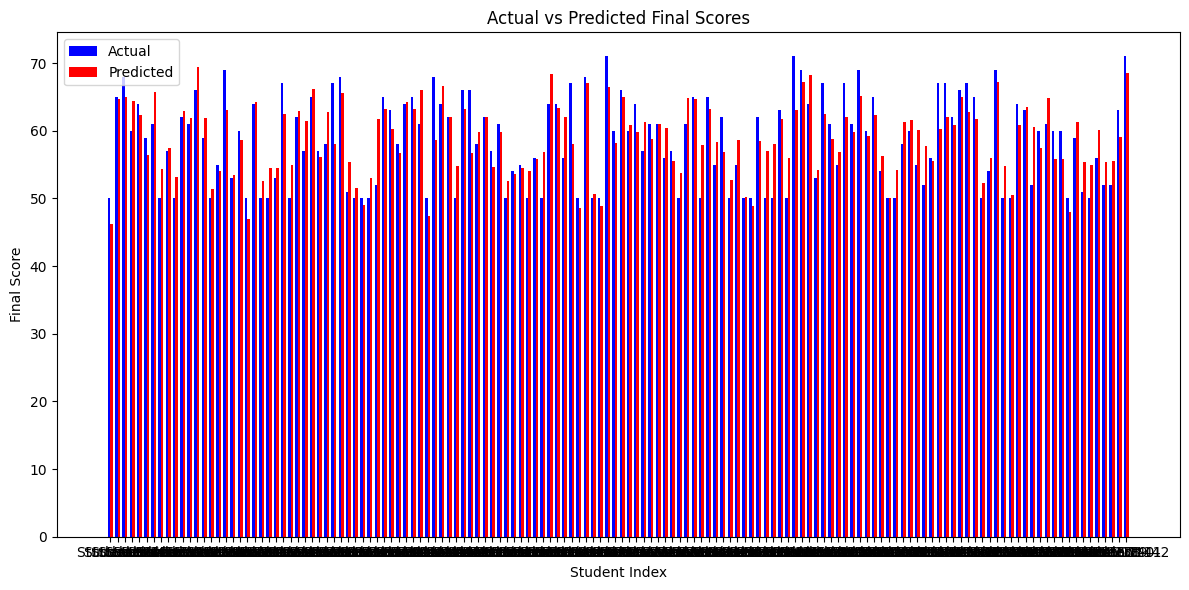

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = pd.read_csv('students_data.csv')

# Features and target
X = data[['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores']]
y = data['Final_Exam_Score']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(x_train, y_train)

# Predict
predictions = model.predict(x_test)

# ─────────────────────────────────────────
#   Model Accuracy
# ─────────────────────────────────────────
r2  = r2_score(y_test, predictions) * 100
mae = mean_absolute_error(y_test, predictions)

print("=" * 40)
print("        MODEL ACCURACY REPORT")
print("=" * 40)
print(f"  R² Accuracy Score : {r2:.2f}%")
print(f"  Mean Avg Error    : {mae:.2f} marks")
print("=" * 40)

# Bar Graph: Actual vs Predicted
indices = np.arange(len(y_test))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(indices, y_test.values, width=bar_width, color='blue', label='Actual')
plt.bar(indices + bar_width, predictions, width=bar_width, color='red', label='Predicted')

plt.xlabel('Student Index')
plt.ylabel('Final Score')
plt.title('Actual vs Predicted Final Scores')
plt.xticks(indices + bar_width / 2, [f'Student {i+1}' for i in indices])
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
